In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

df = pd.read_csv("Titanic.csv")

print("First 5 rows of the dataset:")
print(df.head())
print("\n")

print("Dataset information:")
print(df.info())
print("\n")

print("Statistical summary:")
print(df.describe())
print("\n")


df = df.dropna(subset=["age", "embarked", "cabin"])

df = df.drop_duplicates()


df["age"] = df["age"].astype(int)
df["fare"] = df["fare"].astype(float)

Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["fare"] >= lower) & (df["fare"] <= upper)]

df["sex"] = df["sex"].map({"male": 0, "female": 1})

df = pd.get_dummies(df, columns=["embarked"])

scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

df = df.drop(["name", "ticket"], axis=1)

df["FamilySize"] = df["sibsp"] + df["parch"] + 1

X = df.drop("survived", axis=1)
y = df["survived"]

print("Features:")
print(X.head())
print("\n")

print("Target:")
print(y.head())
print("\n")

df.to_csv("Cleaned_Titanic.csv", index=False)

print("Data preprocessing completed successfully.")
print("\n")

First 5 rows of the dataset:
   goo  survived                                             name     sex  \
0    1         1                    Allen, Miss. Elisabeth Walton  female   
1    1         1                   Allison, Master. Hudson Trevor    male   
2    1         0                     Allison, Miss. Helen Loraine  female   
3    1         0             Allison, Mr. Hudson Joshua Creighton    male   
4    1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0             

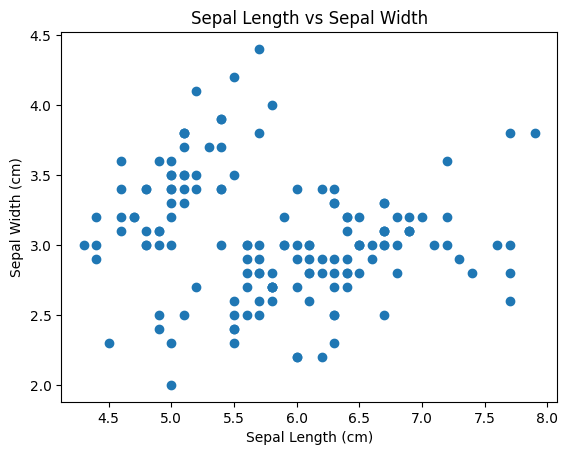

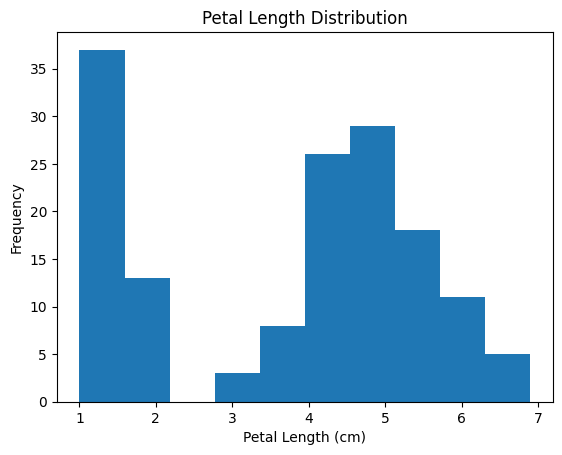

/tmp/ipykernel_4229/2520560378.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species)


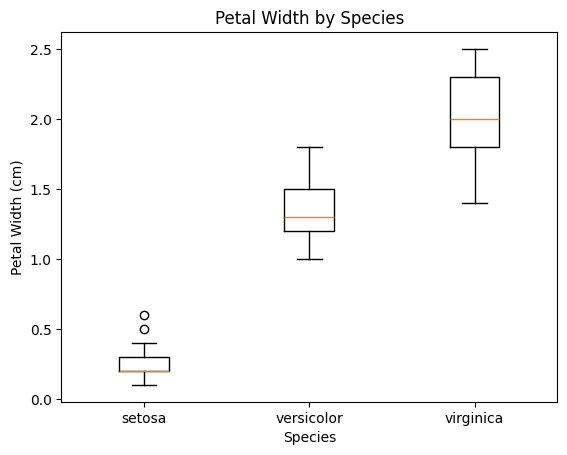

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


iris = load_iris()


df = pd.DataFrame(iris.data, columns=iris.feature_names)


df["species"] = iris.target
df["species"] = df["species"].replace({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})


plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"])
plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()


plt.hist(df["petal length (cm)"], bins=10)
plt.title("Petal Length Distribution")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Frequency")
plt.show()


species = df["species"].unique()

data = []

for s in species:
    data.append(df[df["species"] == s]["petal width (cm)"])

plt.boxplot(data, labels=species)
plt.title("Petal Width by Species")
plt.xlabel("Species")
plt.ylabel("Petal Width (cm)")
plt.show()

In [ ]:
import numpy as np


arr = np.random.randint(1, 100, (4, 4))

print("Original Array:")
print(arr)


print("Mean =", np.mean(arr))


print("Median =", np.median(arr))


print("Standard Deviation =", np.std(arr))


print("\nArray + 10")
print(arr + 10)


print("\nArray * 2")
print(arr * 2)


new_arr = arr.reshape(2, 8)

print("\nReshaped Array:")
print(new_arr)

s
result = np.matmul(arr, arr)

print("\nMatrix Multiplication:")
print(result)

Original Array:
[[63 62  9 61]
 [16 56 82 49]
 [86 80 38 12]
 [66 19  8 22]]
Mean = 45.5625
Median = 52.5
Standard Deviation = 26.886262175133233

Array + 10
[[73 72 19 71]
 [26 66 92 59]
 [96 90 48 22]
 [76 29 18 32]]

Array * 2
[[126 124  18 122]
 [ 32 112 164  98]
 [172 160  76  24]
 [132  38  16  44]]

Reshaped Array:
[[63 62  9 61 16 56 82 49]
 [86 80 38 12 66 19  8 22]]

Matrix Multiplication:
[[ 9761  9257  6481  8331]
 [12190 11619  8244  5782]
 [10758 13080  8874  9886]
 [ 6602  6214  2632  5537]]
